In [184]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.model_selection import KFold
from sklearn import linear_model #New!
from sklearn.linear_model import HuberRegressor
import time

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold, StratifiedKFold
from astroML.linear_model import LinearRegression, PolynomialRegression, BasisFunctionRegression, NadarayaWatson
import sklearn.gaussian_process as gp
from sklearn.pipeline import make_pipeline #This allows one to build different steps together
from sklearn.model_selection import GridSearchCV # New! This will be used to explore different hyperparameter choices.
from sklearn.gaussian_process.kernels import RBF
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit

In [185]:
data = pd.read_csv("mu_z_data.csv")
data

,z,mu,dmu,mu_true
0,0.574163,41.508560,0.952364,42.623144
1,0.739362,44.163474,0.965868,43.292384
2,0.622291,43.277566,0.956642,42.835220
3,0.570798,41.140047,0.952053,42.607699
4,0.473621,43.513582,0.942226,42.120245
...,...,...,...,...
95,0.292415,41.499929,0.917491,40.891384
96,0.607380,42.000001,0.955351,42.771219
97,0.113116,37.975502,0.871529,38.601749
98,0.903093,43.388113,0.976660,43.826842


In [186]:
data = data.drop("dmu",axis = 1)
data

,z,mu,mu_true
0,0.574163,41.508560,42.623144
1,0.739362,44.163474,43.292384
2,0.622291,43.277566,42.835220
3,0.570798,41.140047,42.607699
4,0.473621,43.513582,42.120245
...,...,...,...
95,0.292415,41.499929,40.891384
96,0.607380,42.000001,42.771219
97,0.113116,37.975502,38.601749
98,0.903093,43.388113,43.826842


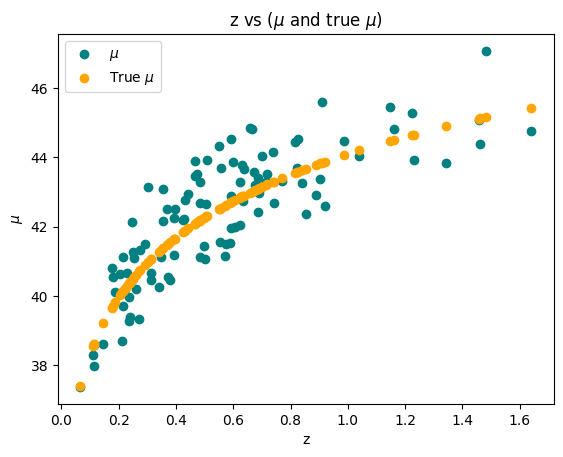

In [187]:
plt.title(r"z vs ($\mu$ and true $\mu$)")
plt.scatter(data['z'],data['mu'],color='teal', label=r'$\mu$')
plt.scatter(data['z'],data['mu_true'], color='orange', label=r'True $\mu$');
plt.xlabel('z')
plt.ylabel(r'$\mu$');
plt.legend();

In [188]:
y = np.array(data['mu'])
X = np.array(data['z']).reshape(-1, 1)

kernel1 = gp.kernels.RBF()

model = gp.GaussianProcessRegressor(kernel=kernel1, alpha=1) # alpha is to account for noisemodel.fit(X, y)
y_pred = model.predict(X)

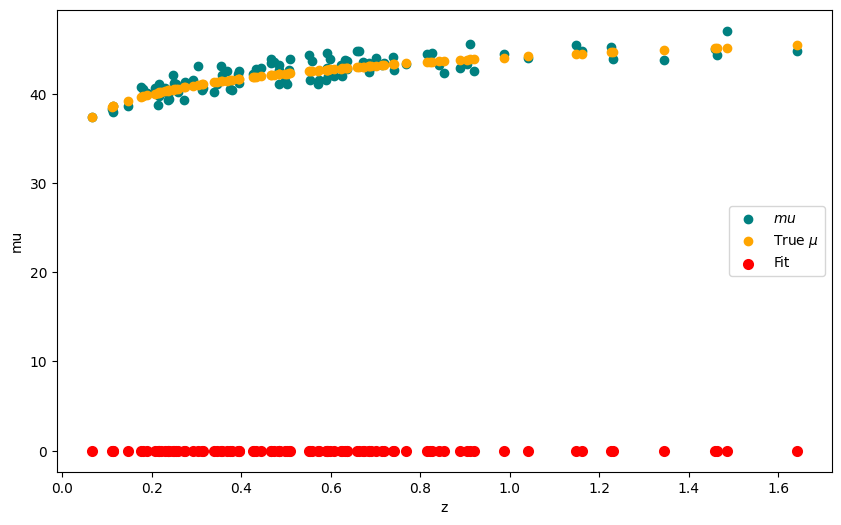

In [189]:
# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label=r'$mu$', color='teal')
plt.scatter(data['z'], data['mu_true'], label = r'True $\mu$', color='orange')
plt.scatter(X, y_pred, linestyle='-', linewidth=2, label='Fit', color='red')
plt.xlabel('z')
plt.ylabel('mu')
plt.legend();
plt.show();

In [190]:
kernel1 = RBF(length_scale=100)
results = []

alpha = np.logspace(-3, 3, 100)
alpha

array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226722e-02, 1.23284674e-02, 1.41747416e-02,
       1.62975083e-02, 1.87381742e-02, 2.15443469e-02, 2.47707636e-02,
       2.84803587e-02, 3.27454916e-02, 3.76493581e-02, 4.32876128e-02,
       4.97702356e-02, 5.72236766e-02, 6.57933225e-02, 7.56463328e-02,
       8.69749003e-02, 1.00000000e-01, 1.14975700e-01, 1.32194115e-01,
       1.51991108e-01, 1.74752840e-01, 2.00923300e-01, 2.31012970e-01,
       2.65608778e-01, 3.05385551e-01, 3.51119173e-01, 4.03701726e-01,
       4.64158883e-01, 5.33669923e-01, 6.13590727e-01, 7.05480231e-01,
       8.11130831e-01, 9.32603347e-01, 1.07226722e+00, 1.23284674e+00,
       1.41747416e+00, 1.62975083e+00, 1.87381742e+00, 2.15443469e+00,
      

In [191]:
import warnings
warnings.filterwarnings('ignore')

for a in alpha:
    model = gp.GaussianProcessRegressor(kernel=kernel1, alpha=a)
    scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
    mse = -scores.mean()
    results.append(mse)

In [192]:
# Find best alpha
best_alpha = alpha[np.argmin(results)]
print(f"Best alpha: {best_alpha}")

best_model = gp.GaussianProcessRegressor(kernel=kernel1, alpha=best_alpha, random_state=42)
best_model.fit(X, y)

y_pred_best = best_model.predict(X)

Best alpha: 0.004641588833612782


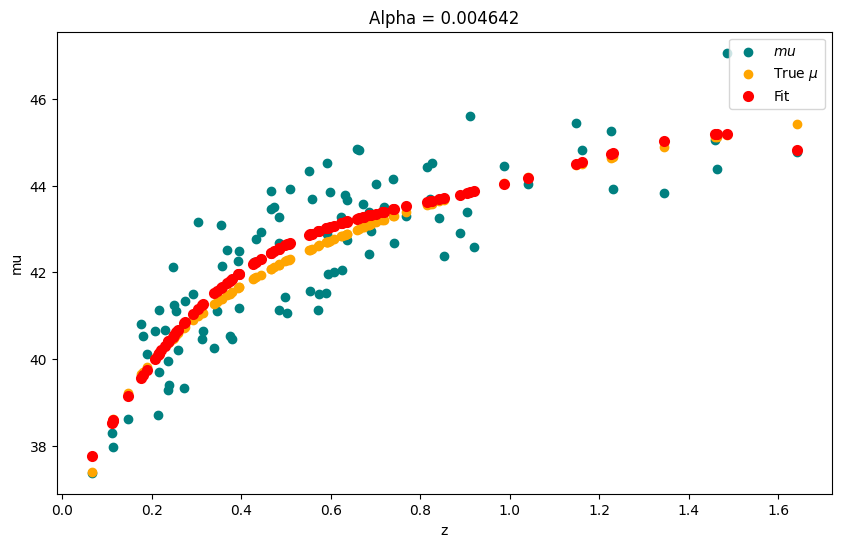

In [193]:
# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label=r'$mu$', color='teal')
plt.scatter(data['z'], data['mu_true'], label = r'True $\mu$', color='orange')
plt.scatter(X, y_pred_best, linestyle='-', linewidth=2, label='Fit', color='red')
plt.xlabel('z')
plt.ylabel('mu')
plt.legend();
plt.title(f"Alpha = {best_alpha:.6f}")
plt.show();

In [194]:
model_final = gp.GaussianProcessRegressor(kernel=kernel1, alpha=best_alpha)

(-1.0, 0.0)

<Figure size 640x480 with 0 Axes>

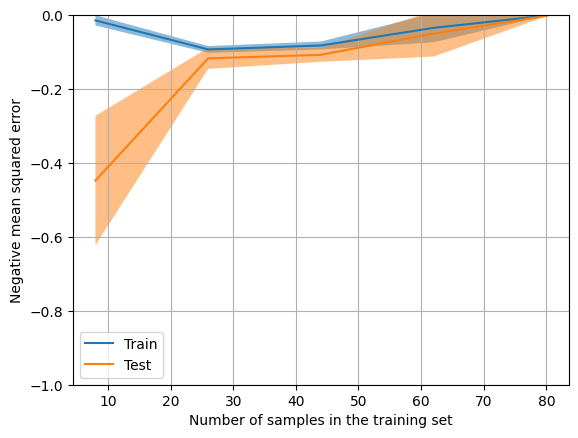

In [195]:
fig = plt.figure()
LearningCurveDisplay.from_estimator(model_final,X,y_pred_best,cv=5,scoring='neg_mean_squared_error')
plt.grid()
plt.ylim(-1,0)